# Training — EfficientNet-B0 Head Fine-Tuning (model Proposed)
Notebook ini melatih ulang **projection head** di atas backbone EfficientNet-B0 yang dibekukan, pakai **batch-hard triplet loss** pada gabungan CEDAR + GPDS + dataset lokal (221 penulis). Ini mereproduksi model **Proposed** di paper.

> **Catatan:** notebook menyimpan hasil ke `CodeTrain/EfficientNet-B0-head-ft-reproduced.pth` (file **terpisah**, tidak menimpa `EfficientNet-B0-head-ft.pth` yang dipakai web/paper). Angka evaluasi akhir bisa **sedikit berbeda** dari Tabel II paper (±0.01) karena checkpoint terbaik bisa jatuh di step yang sedikit berbeda; keduanya menggunakan skrip evaluasi yang sama.

Isi: setup → cache fitur backbone → split penulis (188 train / 33 held-out) → **loop training + grafik** → evaluasi akhir (Tabel II).

## 1. Setup & konfigurasi

In [1]:
import os, glob, re, itertools, random, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as tvm
from PIL import Image
import matplotlib.pyplot as plt

# >>> ganti kalau folder project dipindah <<<
PROJ = r'D:/ProjectAI'
CACHE = os.path.join(PROJ, 'Model', '_feat_cache.npz')
BASE_CKPT = os.path.join(PROJ, 'EfficientNet-B0-triplet-v4.pth')  # backbone pretrained (baseline)
# Simpan hasil retraining ke file TERPISAH supaya TIDAK menimpa model yang dipakai
# web/paper (EfficientNet-B0-head-ft.pth). Ini adalah reproduksi metode Proposed.
OUT_CKPT  = os.path.join(PROJ, 'CodeTrain', 'EfficientNet-B0-head-ft-reproduced.pth')
IMG_SIZE, MAX_PER_WRITER, SEED = 224, 12, 42
STEPS, VAL_EVERY = 1500, 150
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cpu')
print('PyTorch', torch.__version__, '| device', device)

PyTorch 2.12.1+cpu | device cpu


## 2. Preprocessing (identik dengan pipeline paper)

In [2]:
_MEAN=torch.tensor([0.485,0.456,0.406]).view(3,1,1); _STD=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
def _load_white_bg(path):
    img=Image.open(path)
    if img.mode in ('RGBA','LA') or (img.mode=='P' and 'transparency' in img.info):
        img=img.convert('RGBA'); a=img.getchannel('A')
        if a.getextrema()[0]<255:
            bl=Image.new('RGBA',img.size,(0,0,0,255)); tr=Image.new('RGBA',img.size,(255,255,255,0))
            img=Image.composite(bl,tr,a); bg=Image.new('RGBA',img.size,(255,255,255,255)); img=Image.alpha_composite(bg,img)
    return img.convert('RGB')
def autocrop(img,size=IMG_SIZE,thr=245,pad=0.08):
    g=np.array(img.convert('L')); m=g<thr
    if m.sum()==0: c=img.convert('L')
    else:
        ys,xs=np.where(m); y0,y1,x0,x1=int(ys.min()),int(ys.max()),int(xs.min()),int(xs.max()); h,w=g.shape
        py=max(2,int((y1-y0+1)*pad)); px=max(2,int((x1-x0+1)*pad))
        y0,y1,x0,x1=max(0,y0-py),min(h-1,y1+py),max(0,x0-px),min(w-1,x1+px)
        c=img.convert('L').crop((x0,y0,x1+1,y1+1))
    cw,ch=c.size; s=max(cw,ch); cv=Image.new('L',(s,s),255); cv.paste(c,((s-cw)//2,(s-ch)//2))
    return cv.resize((size,size),Image.BILINEAR)
def preprocess(path):
    im=autocrop(_load_white_bg(path)).convert('RGB')
    t=torch.from_numpy(np.array(im,dtype=np.float32)/255.0).permute(2,0,1); return (t-_MEAN)/_STD

## 3. Arsitektur (backbone EfficientNet-B0 + projection head)

In [3]:
class Embedder(nn.Module):
    def __init__(self, emb=512, dropout=0.3):
        super().__init__()
        self.backbone=nn.Sequential(tvm.efficientnet_b0(weights=None).features)
        self.head=nn.Sequential(nn.Flatten(), nn.Linear(1280,512), nn.BatchNorm1d(512),
                                nn.ReLU(inplace=True), nn.Dropout(dropout),
                                nn.Linear(512,emb), nn.BatchNorm1d(emb))
    def forward(self,x):
        x=self.backbone(x); x=F.adaptive_avg_pool2d(x,1); return F.normalize(self.head(x),p=2,dim=1)

ck=torch.load(BASE_CKPT, map_location=device, weights_only=False)
base=Embedder(int(ck.get('embedding_dim',512))).to(device)
base.load_state_dict(ck['model_state_dict'], strict=True); base.eval()
print('backbone pretrained dimuat. baseline best_val_acc =', round(ck.get('best_val_acc',0)*100,2), '%')

backbone pretrained dimuat. baseline best_val_acc = 88.49 %


## 4. Data & cache fitur backbone (dibekukan)
Fitur 1.280-d dihitung sekali lalu di-cache, sehingga training head cepat di CPU.

In [4]:
def gather():
    data={}
    for w in glob.glob(os.path.join(PROJ,'DataSets','GPDS','*')+os.sep):
        wid='gpds_'+os.path.basename(w.rstrip(os.sep)); imgs=sorted(glob.glob(os.path.join(w,'genuine','*')))
        if len(imgs)>=2: data[wid]=imgs[:MAX_PER_WRITER]
    ced={}
    for p in glob.glob(os.path.join(PROJ,'DataSets','Cedar','full_org','*.png')):
        mo=re.match(r'original_(\d+)_',os.path.basename(p))
        if mo: ced.setdefault('cedar_'+mo.group(1),[]).append(p)
    for k,v in ced.items():
        if len(v)>=2: data[k]=sorted(v)[:MAX_PER_WRITER]
    for w in glob.glob(os.path.join(PROJ,'DataSets','Dataset Sendiri','TTD ASLI','*')+os.sep):
        wid='own_'+os.path.basename(w.rstrip(os.sep))
        imgs=[p for p in sorted(glob.glob(os.path.join(w,'*'))) if p.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
        if len(imgs)>=2: data[wid]=imgs[:MAX_PER_WRITER]
    return data
data=gather(); print(len(data),'penulis,',sum(len(v) for v in data.values()),'gambar genuine (cap',MAX_PER_WRITER,'/penulis)')

@torch.no_grad()
def backbone_feat(path):
    x=preprocess(path).unsqueeze(0); return F.adaptive_avg_pool2d(base.backbone(x),1).flatten(1)[0].numpy().astype(np.float32)

if os.path.exists(CACHE):
    z=np.load(CACHE,allow_pickle=True); feats=z['feats']; writers=list(z['writers']); paths=list(z['paths'])
    print('cache dimuat:', feats.shape)
else:
    feats=[]; writers=[]; paths=[]; t0=time.time(); n=sum(len(v) for v in data.values()); i=0
    for wid,imgs in data.items():
        for p in imgs:
            try: feats.append(backbone_feat(p)); writers.append(wid); paths.append(p)
            except Exception: pass
            i+=1;
            if i%200==0: print(f'  {i}/{n} ({time.time()-t0:.0f}s)')
    feats=np.stack(feats); np.savez_compressed(CACHE,feats=feats,writers=np.array(writers),paths=np.array(paths))
    print('cache dibuat:', feats.shape)

221 penulis, 2052 gambar genuine (cap 12 /penulis)
cache dimuat: (2052, 1280)


## 5. Split penulis (188 train / 33 held-out) — seed tetap

In [5]:
random.seed(SEED)
uniq=sorted(set(writers)); random.shuffle(uniq)
n_val=max(20,int(0.15*len(uniq))); val_writers=set(uniq[:n_val]); train_writers=[w for w in uniq if w not in val_writers]
gen_bf={}
for i,w in enumerate(writers): gen_bf.setdefault(w,[]).append(feats[i])
gen_bf={w:np.asarray(v[:6],dtype=np.float32) for w,v in gen_bf.items() if len(v)>=2}
feat_by_writer={}
for i,w in enumerate(writers):
    if w in train_writers: feat_by_writer.setdefault(w,[]).append(i)
train_ws=[w for w in feat_by_writer if len(feat_by_writer[w])>=2]
print('train', len(train_ws), 'penulis | held-out', len(val_writers), 'penulis')

train 188 penulis | held-out 33 penulis


## 6. Training head (batch-hard triplet) + rekam history

In [6]:
class Head(nn.Module):
    def __init__(self, emb=512, dropout=0.3):
        super().__init__()
        self.net=nn.Sequential(nn.Flatten(), nn.Linear(1280,512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
                               nn.Dropout(dropout), nn.Linear(512,emb), nn.BatchNorm1d(emb))
    def forward(self,x): return F.normalize(self.net(x),p=2,dim=1)

def batch_hard(emb, labels, margin=0.3):
    d=1.0-emb@emb.t(); B=emb.size(0); lab=labels.unsqueeze(0)==labels.unsqueeze(1); eye=torch.eye(B,dtype=torch.bool)
    pos=lab&~eye; neg=~lab; losses=[]
    for i in range(B):
        if pos[i].any() and neg[i].any():
            losses.append(F.relu(d[i][pos[i]].max()-d[i][neg[i]].min()+margin))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,requires_grad=True)

def sample_batch(P=12,K=4):
    ws=random.sample(train_ws,min(P,len(train_ws))); xs=[]; ys=[]
    for j,w in enumerate(ws):
        for k in random.sample(feat_by_writer[w],min(K,len(feat_by_writer[w]))): xs.append(k); ys.append(j)
    return np.array(xs), np.array(ys)

@torch.no_grad()
def val_auc(head):
    head.eval(); embs={}
    for w in val_writers:
        if w in gen_bf: embs[w]=F.normalize(head(torch.from_numpy(gen_bf[w])),p=2,dim=1).numpy()
    same=[float(a@b) for w in embs for a,b in itertools.combinations(embs[w],2)]
    wl=list(embs); diff=[float(embs[wl[x]][i]@embs[wl[y]][0]) for x in range(len(wl)) for y in range(x+1,len(wl)) for i in range(min(2,len(embs[wl[x]])))]
    s=np.array(same+diff); yv=np.array([1]*len(same)+[0]*len(diff)); o=np.argsort(-s); yv=yv[o]
    tp=np.cumsum(yv); fp=np.cumsum(1-yv); tpr=tp/tp[-1]; fpr=fp/fp[-1]
    head.train(); return float(np.sum((fpr[1:]-fpr[:-1])*(tpr[1:]+tpr[:-1])/2))

head=Head(512).to(device); opt=torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
hist_step=[]; hist_loss=[]; val_step=[]; val_hist=[]; best=0.0
t0=time.time()
for step in range(1, STEPS+1):
    xs,ys=sample_batch(); emb=head(torch.from_numpy(feats[xs])); loss=batch_hard(emb, torch.tensor(ys), 0.3)
    opt.zero_grad(); loss.backward(); opt.step()
    hist_step.append(step); hist_loss.append(float(loss.item()))
    if step%VAL_EVERY==0:
        a=val_auc(head); val_step.append(step); val_hist.append(a)
        print(f'step {step:4d} | loss {loss.item():.3f} | val AUC {a:.4f}')
        if a>best:
            best=a; new=Embedder(512); new.backbone.load_state_dict(base.backbone.state_dict()); new.head.load_state_dict(head.net.state_dict())
            torch.save({'model_state_dict':new.state_dict(),'embedding_dim':512,'threshold':0.5,'val_auc':a}, OUT_CKPT)
print(f'selesai dalam {time.time()-t0:.0f}s | best val AUC = {best:.4f} -> {OUT_CKPT}')

step  150 | loss 0.086 | val AUC 0.9746


step  300 | loss 0.080 | val AUC 0.9741


step  450 | loss 0.043 | val AUC 0.9721


step  600 | loss 0.089 | val AUC 0.9749


step  750 | loss 0.017 | val AUC 0.9724


step  900 | loss 0.027 | val AUC 0.9725


step 1050 | loss 0.017 | val AUC 0.9723


step 1200 | loss 0.018 | val AUC 0.9729


step 1350 | loss 0.035 | val AUC 0.9717


step 1500 | loss 0.005 | val AUC 0.9734
selesai dalam 152s | best val AUC = 0.9749 -> D:/ProjectAI\CodeTrain\EfficientNet-B0-head-ft-reproduced.pth


## 7. Grafik training (loss & validation AUC)

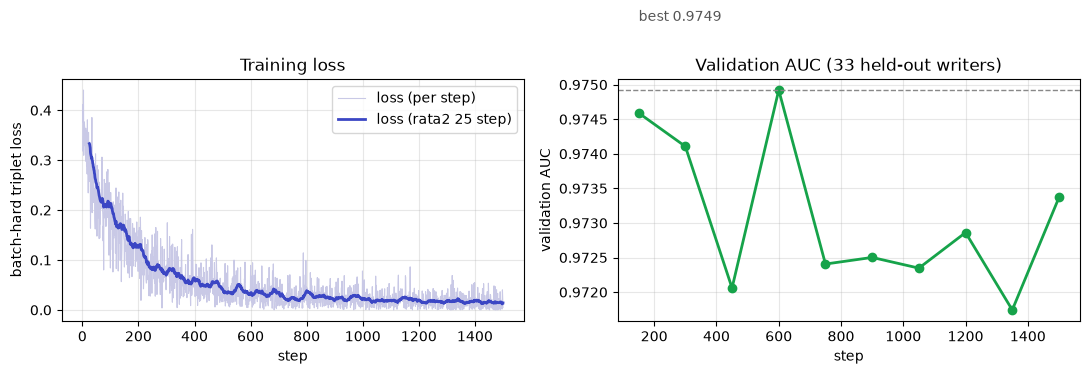

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
sm=np.convolve(hist_loss,np.ones(25)/25,mode='valid')
ax[0].plot(hist_step,hist_loss,color='#c9c9e6',lw=0.8,label='loss (per step)')
ax[0].plot(hist_step[24:],sm,color='#3b46c4',lw=2,label='loss (rata2 25 step)')
ax[0].set_xlabel('step'); ax[0].set_ylabel('batch-hard triplet loss'); ax[0].set_title('Training loss'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(val_step,val_hist,'o-',color='#16a34a',lw=2)
ax[1].set_xlabel('step'); ax[1].set_ylabel('validation AUC'); ax[1].set_title('Validation AUC (33 held-out writers)'); ax[1].grid(alpha=.3)
ax[1].axhline(best,ls='--',color='#888',lw=1); ax[1].text(val_step[0],best+0.001,f'best {best:.4f}',color='#555')
plt.tight_layout(); plt.savefig(os.path.join(PROJ,'training_curves_head_ft.png'),dpi=130,bbox_inches='tight'); plt.show()

## 8. Evaluasi akhir — Tabel II paper (Baseline vs Proposed, Random vs Skilled)

In [8]:
ftm=Embedder(512); ftm.load_state_dict(torch.load(OUT_CKPT,map_location=device,weights_only=False)['model_state_dict'],strict=True); ftm.eval()
def forg_paths(wid):
    k,num=wid.split('_',1)
    if k=='gpds': return sorted(glob.glob(os.path.join(PROJ,'DataSets','GPDS',num,'forge','*')))[:6]
    if k=='cedar': return sorted(glob.glob(os.path.join(PROJ,'DataSets','Cedar','full_forg',f'forgeries_{num}_*.png')))[:6]
    return []
forg_bf={}
for w in val_writers:
    fps=forg_paths(w)
    if fps and w in gen_bf: forg_bf[w]=np.asarray([backbone_feat(p) for p in fps],dtype=np.float32)
@torch.no_grad()
def embed_bf(head,bf): return F.normalize(head(torch.from_numpy(bf)),p=2,dim=1).numpy()
def auc_of(pos,neg):
    s=np.array(pos+neg); y=np.array([1]*len(pos)+[0]*len(neg)); o=np.argsort(-s); y=y[o]
    tp=np.cumsum(y); fp=np.cumsum(1-y); tpr=tp/tp[-1]; fpr=fp/fp[-1]; return float(np.sum((fpr[1:]-fpr[:-1])*(tpr[1:]+tpr[:-1])/2))
def eer_thr(pos,neg):
    best=None
    for t in np.unique(np.array(pos+neg)):
        far=np.mean(np.array(neg)>=t); frr=np.mean(np.array(pos)<t); d=abs(far-frr)
        if best is None or d<best[0]: best=(d,float(t),(far+frr)/2)
    return best[2],best[1]
def at(pos,neg,thr):
    pos=np.array(pos); neg=np.array(neg); TP=int((pos>=thr).sum()); FN=int((pos<thr).sum()); TN=int((neg<thr).sum()); FP=int((neg>=thr).sum())
    acc=(TP+TN)/(TP+FN+TN+FP); pr=TP/(TP+FP) if TP+FP else 0; rc=TP/(TP+FN) if TP+FN else 0; f1=2*pr*rc/(pr+rc) if pr+rc else 0
    return acc,pr,rc,f1
def evaluate(head):
    # PENTING: hanya penulis HELD-OUT (33) — jangan ikutkan penulis training (bocor).
    ge={w:embed_bf(head,gen_bf[w]) for w in gen_bf if w in val_writers}; fe={w:embed_bf(head,forg_bf[w]) for w in forg_bf}
    wl=list(ge); pos=[float(e[a]@e[b]) for w in wl for a,b in itertools.combinations(range(len(ge[w])),2) for e in [ge[w]]]
    negr=[float(ge[wl[x]][a]@ge[wl[y]][b]) for x in range(len(wl)) for y in range(x+1,len(wl)) for a in range(min(3,len(ge[wl[x]]))) for b in range(min(3,len(ge[wl[y]])))]
    negs=[float(ge[w][a]@fe[w][b]) for w in fe for a in range(min(3,len(ge[w]))) for b in range(len(fe[w]))]
    rng=np.random.RandomState(0)
    def bal(n): n=list(n); return [n[i] for i in rng.choice(len(n),len(pos),replace=False)] if len(n)>len(pos) else n
    negr,negs=bal(negr),bal(negs); _,thr=eer_thr(pos,negr+negs)
    out={}
    for name,neg in [('Random',negr),('Skilled',negs)]:
        acc,pr,rc,f1=at(pos,neg,thr); out[name]=(auc_of(pos,neg),eer_thr(pos,neg)[0],acc,pr,rc,f1)
    return out
print(f"{'Model':9s} {'Scenario':8s} {'AUC':>6s} {'EER%':>6s} {'Acc%':>6s} {'Prec%':>6s} {'Rec%':>6s} {'F1%':>6s}")
for tag,m in [('Baseline',base),('Proposed',ftm)]:
    r=evaluate(m.head)
    for sc in ['Random','Skilled']:
        a,e,ac,pr,rc,f1=r[sc]; print(f'{tag:9s} {sc:8s} {a:6.3f} {e*100:6.2f} {ac*100:6.2f} {pr*100:6.2f} {rc*100:6.2f} {f1*100:6.2f}')

Model     Scenario    AUC   EER%   Acc%  Prec%   Rec%    F1%


Baseline  Random    0.953  10.71  87.07  92.38  80.81  86.21
Baseline  Skilled   0.813  25.86  74.55  71.81  80.81  76.05


Proposed  Random    0.972   7.27  89.39  95.14  83.03  88.67
Proposed  Skilled   0.856  22.63  76.67  73.66  83.03  78.06
